# Quadratic Wasserstein versus classical square-root transport

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2025 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook compares two couplings between the same one-dimensional Gaussian-mixture marginals on a common grid. The quadratic Wasserstein plan solves
$$
P_{W_2}\in\mathop{\rm argmin}_{P\in U(a,b)}\sum_{i,j}|x_i-x_j|^2P_{i,j},
$$
whereas the diagonal restriction of quantum transport solves the convex square-root problem
$$
P_{\rm cl}\in\mathop{\rm argmin}_{P\in U(a,b)}
\sum_{i<j}|x_i-x_j|^2\bigl(\sqrt{P_{i,j}}-\sqrt{P_{j,i}}\bigr)^2.
$$
The latter is not an ordinary Kantorovich problem: it couples each entry to its transposed entry.

In [1]:
# --- OT4ML lightweight Colab bootstrap: one shared core, no repository clone.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)


def _ot4ml_find_core():
    """Locate the single shared figure core in a local checkout."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (base / "notebooks-figures" / "figure_style.py", base / "figure_style.py"):
            if candidate.exists():
                return candidate
    return None


def _ot4ml_download_core(target):
    """Download only the shared figure core, never the full repository."""
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main/notebooks-figures/figure_style.py",
        "https://www.gpeyre.com/ot4ml/notebooks-figures/figure_style.py",
    )
    errors = []
    for url in urls:
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                target.write_bytes(response.read())
            return target
        except Exception as error:
            errors.append(f"{url}: {error}")
    raise RuntimeError("Unable to download the OT4ML figure core.\n" + "\n".join(errors))


_OT4ML_CORE = _ot4ml_find_core()
if _OT4ML_CORE is None:
    _OT4ML_CORE = _ot4ml_download_core(
        _OT4ML_Path("/content/ot4ml-figure-runtime/notebooks-figures/figure_style.py")
    )

_OT4ML_SPEC = _OT4ML_importlib_util.spec_from_file_location("figure_style", _OT4ML_CORE)
if _OT4ML_SPEC is None or _OT4ML_SPEC.loader is None:
    raise RuntimeError(f"Cannot load OT4ML figure core from {_OT4ML_CORE}")
_OT4ML_STYLE = _OT4ML_importlib_util.module_from_spec(_OT4ML_SPEC)
_OT4ML_sys.modules["figure_style"] = _OT4ML_STYLE
_OT4ML_SPEC.loader.exec_module(_OT4ML_STYLE)

_OT4ML_PACKAGES = (
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('IPython', 'ipython'),
    ('cvxpy', 'cvxpy'),
)
_OT4ML_REQUIRED_FILES = (

)
ROOT = _OT4ML_STYLE.configure_notebook(
    packages=_OT4ML_PACKAGES,
    required_files=_OT4ML_REQUIRED_FILES,
)
FIGROOT = ROOT / "notebooks-figures"
NOTEBOOK_DIR = FIGROOT


## Marginals and one-dimensional Wasserstein plan

The source and target use the Gaussian mixtures employed throughout the book's one-dimensional coupling figures. Since the grid is ordered and the ground cost is convex, the quadratic Wasserstein optimizer is the monotone quantile coupling. A north-west sweep computes it exactly for the discretized marginals.

In [2]:
from pathlib import Path
import shutil

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    coupling_box,
    figure_dir,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()


def normal_pdf(x, mean, std):
    """Evaluate a one-dimensional Gaussian density.

    Args:
        x: Evaluation grid.
        mean: Gaussian mean.
        std: Strictly positive Gaussian standard deviation.

    Returns:
        Density values at the grid points.
    """
    x = np.asarray(x, dtype=float)
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2.0 * np.pi))


def mixture_pdf(x, weights, means, stds):
    """Evaluate a normalized Gaussian-mixture density.

    Args:
        x: Evaluation grid.
        weights: Nonnegative mixture weights summing to one.
        means: Component means.
        stds: Strictly positive component standard deviations.

    Returns:
        Mixture density values at the grid points.
    """
    density = np.zeros_like(np.asarray(x, dtype=float))
    for weight, mean, std in zip(weights, means, stds):
        density += weight * normal_pdf(x, mean, std)
    return density


def monotone_plan(a, b, tolerance=1e-14):
    """Compute the monotone coupling between two ordered histograms.

    Args:
        a: Source probability weights.
        b: Target probability weights.
        tolerance: Residual mass below which a bin is considered exhausted.

    Returns:
        The one-dimensional monotone transport plan with marginals ``a`` and ``b``.
    """
    source = np.asarray(a, dtype=float).copy()
    target = np.asarray(b, dtype=float).copy()
    plan = np.zeros((source.size, target.size), dtype=float)
    i = j = 0
    while i < source.size and j < target.size:
        mass = min(source[i], target[j])
        plan[i, j] += mass
        source[i] -= mass
        target[j] -= mass
        if source[i] <= tolerance:
            i += 1
        if j < target.size and target[j] <= tolerance:
            j += 1
    return plan

## Classical square-root plan as a cone program

Introduce one auxiliary variable $z_{i,j}$ for each $i<j$. The constraint
$$
z_{i,j}^2\leq P_{i,j}P_{j,i},\qquad z_{i,j}\geq0,
$$
is a rotated second-order cone. At the minimum it is saturated, so minimizing
$$
\sum_{i<j}|x_i-x_j|^2\bigl(P_{i,j}+P_{j,i}-2z_{i,j}\bigr)
$$
computes the square-root objective exactly. The implementation below imposes the marginal constraints directly and checks their residuals after optimization.

In [3]:
def classical_square_root_value(plan, locations):
    """Evaluate the classical square-root objective of a coupling.

    Args:
        plan: Square coupling matrix on a common support.
        locations: One-dimensional locations indexing both matrix axes.

    Returns:
        Value of the squared-distance classical square-root functional.
    """
    plan = np.asarray(plan, dtype=float)
    locations = np.asarray(locations, dtype=float)
    upper_i, upper_j = np.triu_indices(locations.size, k=1)
    ground_cost = (locations[upper_i] - locations[upper_j]) ** 2
    discrepancy = np.sqrt(plan[upper_i, upper_j]) - np.sqrt(plan[upper_j, upper_i])
    return float(np.sum(ground_cost * discrepancy**2))


def solve_classical_square_root(a, b, locations):
    """Solve the discrete classical square-root transport problem.

    Args:
        a: Source probability weights on ``locations``.
        b: Target probability weights on the same locations.
        locations: Ordered one-dimensional support shared by both marginals.

    Returns:
        A pair ``(plan, value)`` containing an optimal coupling and its objective value.

    Raises:
        RuntimeError: If the cone solver does not return an optimal solution.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    locations = np.asarray(locations, dtype=float)
    if a.shape != b.shape or a.shape != locations.shape:
        raise ValueError("The marginals and common support must have identical shapes.")

    size = locations.size
    upper_i, upper_j = np.triu_indices(size, k=1)
    plan = cp.Variable((size, size), nonneg=True)
    geometric_mean = cp.Variable(upper_i.size, nonneg=True)
    forward = plan[upper_i, upper_j]
    backward = plan[upper_j, upper_i]

    # ||(2z, u-v)||_2 <= u+v is equivalent to z^2 <= uv for u,v,z >= 0.
    constraints = [
        cp.sum(plan, axis=1) == a,
        cp.sum(plan, axis=0) == b,
        cp.SOC(
            forward + backward,
            cp.vstack([2.0 * geometric_mean, forward - backward]),
            axis=0,
        ),
    ]
    ground_cost = (locations[upper_i] - locations[upper_j]) ** 2
    objective = cp.Minimize(
        ground_cost @ (forward + backward - 2.0 * geometric_mean)
    )
    problem = cp.Problem(objective, constraints)
    problem.solve(
        solver="CLARABEL",
        tol_gap_abs=2e-8,
        tol_gap_rel=2e-8,
        tol_feas=2e-8,
        max_iter=500,
    )
    if problem.status not in {cp.OPTIMAL, cp.OPTIMAL_INACCURATE}:
        raise RuntimeError(f"Cone solver failed with status {problem.status!r}.")
    return np.maximum(np.asarray(plan.value), 0.0), float(problem.value)


### Numerical instance and verification

A negligible full-support floor stabilizes the rotated cones in the far Gaussian tails. After solving, the code reports both marginal residuals; this makes solver accuracy explicit rather than relying only on the rendered matrix.

In [4]:
alpha_parameters = {
    "weights": [0.50, 0.35, 0.15],
    "means": [-1.55, -0.20, 1.08],
    "stds": [0.26, 0.42, 0.22],
}
beta_parameters = {
    "weights": [0.22, 0.50, 0.28],
    "means": [-1.03, 0.72, 1.82],
    "stds": [0.21, 0.36, 0.30],
}

number_of_bins = 96
locations = np.linspace(-2.75, 2.75, number_of_bins)
a = mixture_pdf(locations, **alpha_parameters)
b = mixture_pdf(locations, **beta_parameters)

# A negligible full-support floor improves the conditioning of the rotated cones
# in the far Gaussian tails without changing the visible marginals.
a += 1e-4 * a.max()
b += 1e-4 * b.max()
a /= a.sum()
b /= b.sum()

plan_w2 = monotone_plan(a, b)
plan_classical, classical_value = solve_classical_square_root(a, b, locations)
quadratic_value = np.sum(
    (locations[:, None] - locations[None, :]) ** 2 * plan_w2
)
classical_value_at_w2 = classical_square_root_value(plan_w2, locations)
relative_improvement = 1.0 - classical_value / classical_value_at_w2

row_residual = np.max(np.abs(plan_classical.sum(axis=1) - a))
column_residual = np.max(np.abs(plan_classical.sum(axis=0) - b))
print(f"W2 squared value: {quadratic_value:.6f}")
print(f"Classical objective at the W2 plan: {classical_value_at_w2:.6f}")
print(f"Optimal classical square-root value: {classical_value:.6f}")
print(f"Relative decrease from re-optimizing: {relative_improvement:.1%}")
print(f"Maximum row residual: {row_residual:.2e}")
print(f"Maximum column residual: {column_residual:.2e}")

W2 squared value: 1.937686
Classical objective at the W2 plan: 1.937686
Optimal classical square-root value: 1.352929
Relative decrease from re-optimizing: 30.2%
Maximum row residual: 2.00e-08
Maximum column residual: 5.73e-09


## Coupling comparison

Both panels use the same intensity scale and power transform. The red strip is the source marginal $a$, the blue strip is the target marginal $b$, and the framed square is the coupling. The quadratic Wasserstein optimizer follows the monotone graph expected in one dimension. The square-root optimizer instead develops reciprocal, nonmonotone branches because its objective rewards agreement between $P_{i,j}$ and $P_{j,i}$.

In [5]:
def draw_marginal_strips(ax, source, target, rows, columns):
    """Attach source and target density profiles to a coupling square.

    Args:
        ax: Matplotlib axes receiving the marginal strips.
        source: Source marginal shown along the left side.
        target: Target marginal shown along the top side.
        rows: Number of source bins.
        columns: Number of target bins.

    Returns:
        None. The function modifies ``ax`` in place.
    """
    marginal_width = 0.15
    gap = 0.018
    row_coordinates = np.arange(rows)
    column_coordinates = np.arange(columns)

    left_edge = -0.5 - gap * columns
    left_scale = marginal_width * columns / source.max()
    ax.fill_betweenx(
        row_coordinates,
        left_edge,
        left_edge - left_scale * source,
        color=RED,
        alpha=0.20,
        linewidth=0,
    )
    ax.plot(left_edge - left_scale * source, row_coordinates, color=RED, lw=1.0)

    top_edge = rows - 0.5 + gap * rows
    top_scale = marginal_width * rows / target.max()
    ax.fill_between(
        column_coordinates,
        top_edge,
        top_edge + top_scale * target,
        color=BLUE,
        alpha=0.20,
        linewidth=0,
    )
    ax.plot(column_coordinates, top_edge + top_scale * target, color=BLUE, lw=1.0)

The matrix renderer uses one normalization for both plans and suppresses only solver-level pixels. Keeping marginal rendering separate makes the geometric comparison independent of display decoration.

In [6]:
def draw_coupling_with_marginals(
    ax,
    plan,
    source,
    target,
    *,
    maximum,
    title,
    gamma=0.42,
    display_floor=1e-5,
):
    """Draw a square coupling matrix with attached source and target marginals.

    Args:
        ax: Matplotlib axes receiving the panel.
        plan: Coupling matrix to display.
        source: Source marginal shown along the left side.
        target: Target marginal shown along the top side.
        maximum: Common normalization shared by all compared plans.
        title: Mathematical title displayed above the panel.
        gamma: Power used to reveal small but meaningful coupling entries.
        display_floor: Relative threshold suppressing solver-level numerical pixels.

    Returns:
        None. The function modifies ``ax`` in place.
    """
    rows, columns = plan.shape
    visible = np.where(plan >= display_floor * maximum, plan, 0.0)
    image = np.clip(visible / maximum, 0.0, 1.0) ** gamma
    ax.imshow(
        image,
        cmap="Greys",
        origin="lower",
        extent=(-0.5, columns - 0.5, -0.5, rows - 0.5),
        interpolation="nearest",
        vmin=0.0,
        vmax=1.0,
    )
    coupling_box(ax, rows, columns, linewidth=0.7)
    draw_marginal_strips(ax, source, target, rows, columns)

    ax.set_xlim(-0.5 - 0.20 * columns, columns - 0.5)
    ax.set_ylim(-0.5, rows - 0.5 + 0.20 * rows)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, color=VIOLET, fontsize=12, pad=7)

### Export

The final cell places the two square panels on one line, exports the vector figure used by both book variants, and writes a lightweight PNG preview for the notebook index.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


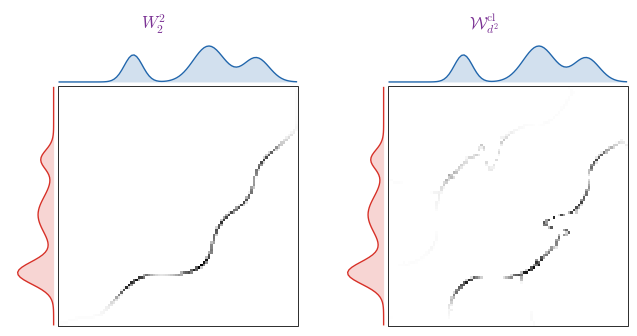

Wrote /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/quantum-classical-square-root-transport/comparison.pdf
Wrote /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/quantum-classical-square-root-transport.png


In [7]:
figure_name = "quantum-classical-square-root-transport"
output_directory = figure_dir(figure_name)
common_maximum = max(plan_w2.max(), plan_classical.max())

figure, axes = plt.subplots(1, 2, figsize=(6.6, 3.25), constrained_layout=True)
draw_coupling_with_marginals(
    axes[0],
    plan_w2,
    a,
    b,
    maximum=common_maximum,
    title=r"$W_2^2$",
)
draw_coupling_with_marginals(
    axes[1],
    plan_classical,
    a,
    b,
    maximum=common_maximum,
    title=r"$\mathcal{W}_{d^2}^{\mathrm{cl}}$",
)

pdf_path = output_directory / "comparison.pdf"
save_pdf(figure, pdf_path, pad_inches=0.045)

arxiv_directory = ROOT / "arxiv" / "figures"
arxiv_directory.mkdir(parents=True, exist_ok=True)
shutil.copyfile(
    pdf_path,
    arxiv_directory / f"{figure_name}--comparison.pdf",
)

thumbnail_path = FIGROOT / "thumbnails" / f"{figure_name}.png"
figure.savefig(thumbnail_path, dpi=190, bbox_inches="tight", pad_inches=0.045)
plt.show()
print(f"Wrote {pdf_path}")
print(f"Wrote {thumbnail_path}")

## Interpretation

The right-hand optimizer is visibly not concentrated near a single monotone graph. This is consistent with the variational structure: unlike ordinary optimal transport, the square-root objective is nonlinear in the coupling and compares $pi$ with its transpose. Therefore Brenier's theorem and the usual cyclical-monotonicity argument do not apply directly. The computation is evidence against a naive monotone-map principle, but it does not prove that every atomless instance lacks a Monge optimizer.

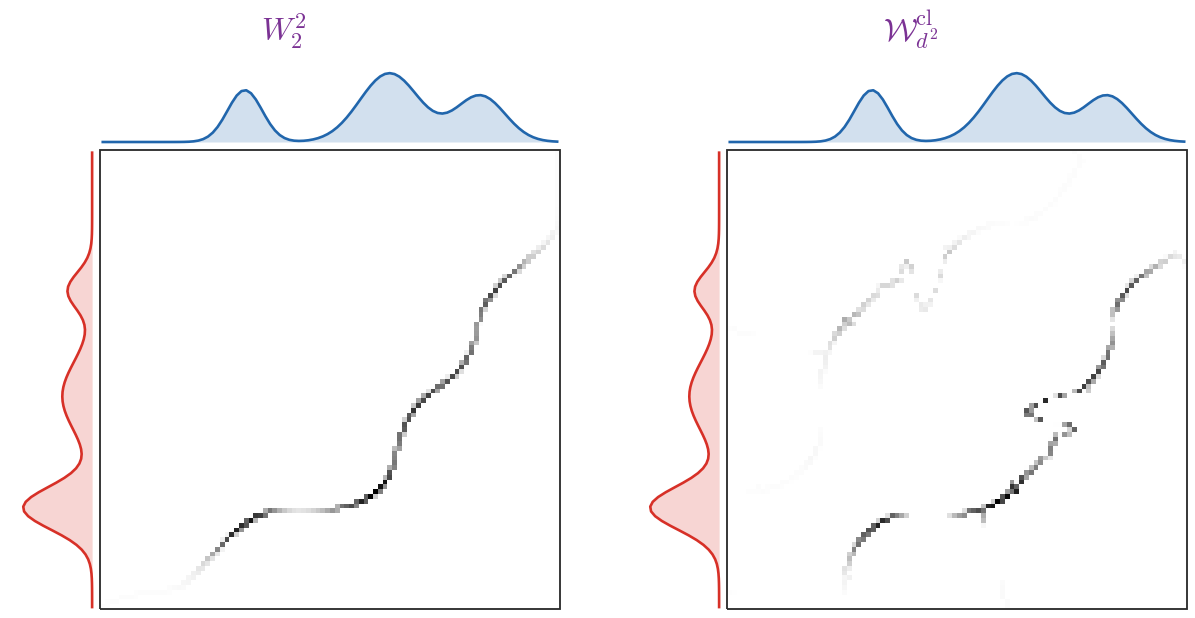

In [8]:
if thumbnail_path.exists():
    display(Image(filename=str(thumbnail_path)))